
Random_state:  64
[[ 20.           2.          45.          10.        ]
 [ 12.          51.           8.          15.        ]
 [ 30.          93.           4.         100.        ]
 [ 32.          18.          45.           6.        ]
 [ 42.         100.         110.         100.        ]
 [  5.         100.          24.           7.        ]
 [ 16.         100.          28.66666667  38.6097561 ]
 [ 95.           3.          20.          45.        ]
 [ 12.          14.           1.          10.        ]
 [  6.          20.          10.         100.        ]]
[[0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]
              precision    recall  f1-score   support

 non-healing       0.00      0.00      0.00         2
     healing       0.75      0.75      0.75         8

   micro avg       0.60      0.60      0.60        10
   macro avg       0.38      0.38      0.38        10
weighted avg       0.60      0.60      0.60        10
 samples avg 

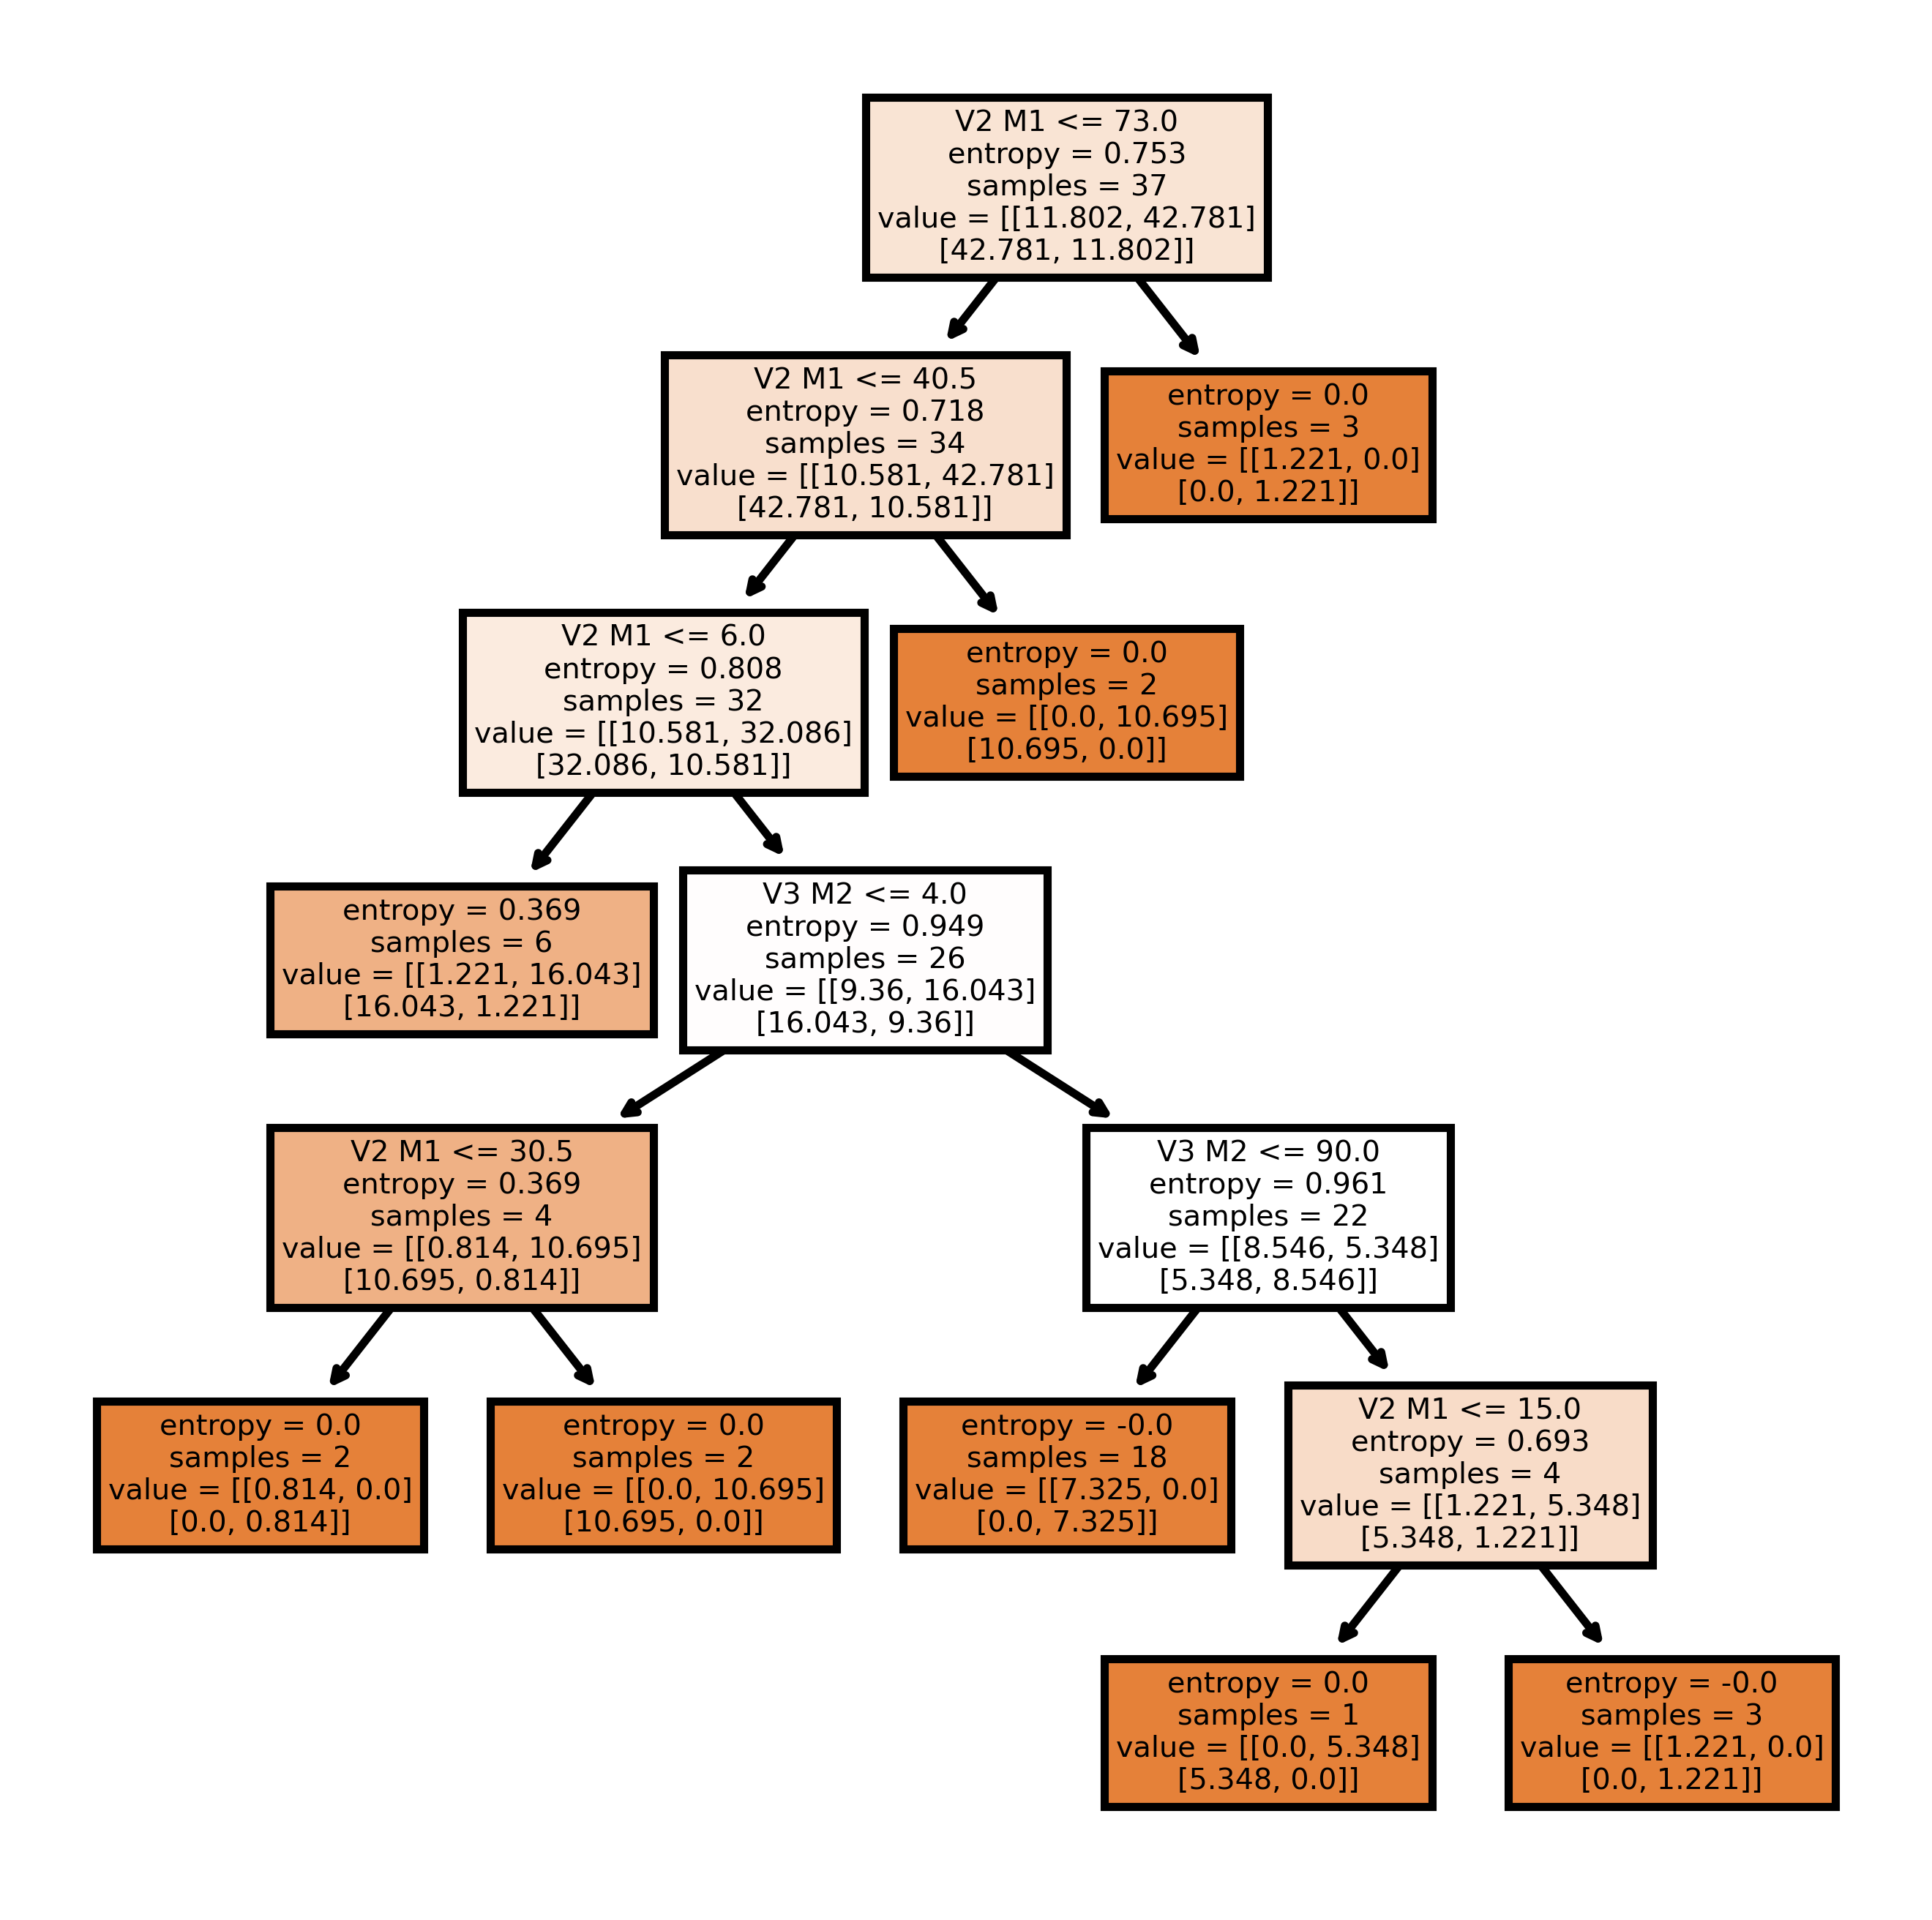

Accuracy: 60.0 %


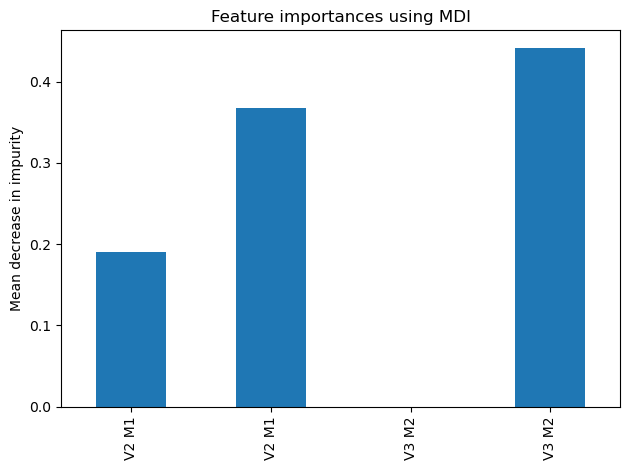

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer


Treatment=pd.read_csv("../dissertation/M1 M2.csv")
df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]

imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(df_x)
df_x=imp.transform(df_x)


R_state=random.randrange(1,100)
print("Random_state: ",R_state)
R_state=25
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y,test_size=0.2, random_state=R_state,stratify=df_y)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print(X_test)
print(y_test)






names=["V2 M1","V2 M1","V3 M2","V3 M2"]



clf=DecisionTreeClassifier(max_depth=None,
                            class_weight="balanced",
                               criterion="entropy",
                              ccp_alpha=0.06,
                  
    )

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["non-healing","healing"]))

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)

tree.plot_tree(clf, filled = True,feature_names=names);
plt.savefig('Tree', dpi=1200)
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)
fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()
target = 'key'
class_names=["non-healing","healing"]

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_train, 
    df_y, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree()